In [1]:
# This is a preview of the code used in the paper "A Unified Framework for Laminar...
# ... Film Condensation on a Vertical Wall: Transition from Gravity-Driven to ...
# ... Vapour-Shear Regimes". Several of the equations presented here are referred to ...
# ... using the numbering adopted in the original document. Only the most basic cases ...
# ... are included in this code.
#
# It should be noted that an additional nomenclature is used, introducing the variable H ...
# ... to represent Ja/Pr, as adopted in previous works. Furthermore, all variables ...
# ... are already expressed under the similarity condition.
#
# Pablo Huerta (March 5, 2026)

# Libraries -----------------------------------------------------------------

import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
from matplotlib import ticker

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


# Symbolic Variables --------------------------------------------------------------

x = sym.Symbol('x') # This corresponds to x* in Eq. (7)
y = sym.Symbol('y') # This corresponds to y* in Eq. (8)
z = sym.Symbol('z') # This corresponds to $\zeta*$ in Eq. (16)

# Nusselt Results (Eq. (36)) ---------------------------------------------------------------

u_Nu = 3.0*y - 1.5*y**2
T_Nu = 1.0 - 1.0*y

# Functions used --------------------------------------------------------------

# This function calculates the variable ${\cal F}$ defined in Eq. (30)

def calc_F(u):
    ui = u.subs({'y':1})
    fa = 5/4*sym.integrate(u*u, (y,y,1)) - 3/4*(ui - u*sym.integrate(u,(y,0,y)))
    F = sym.integrate(fa,(y,0,y))
    return F

# This function calculates the variable ${\cal S}$ defined in Eq. (29), and additionally ...
# ... computes ${\cal M}$ defined in Eq. (26), which depends on ${\cal S}$.

def calc_SM(u, T, Ja):
    ui = u.subs({'y':1})
    sa = 3/4*sym.integrate(u*T,(y,y,1)) + 3/4*T*sym.integrate(u,(y,0,y))
    S = sym.integrate(sa, (y,y,1))
    M = 3/4 + Ja*S.subs({'y':0})
    return S, M

# This function helps fix the order of the polynomial used for the velocity and ...
# ... temperature profiles.
    
def new_poly(func,num,order):
    dy = 1/(num + 1)
    y_array = np.arange(0,1+dy,dy)
    fy_array = [func.subs('y', g).evalf() for g in y_array]
    model_fy = make_pipeline(PolynomialFeatures(order), Ridge(alpha=1E-8, fit_intercept=False))
    model_fy.fit(y_array[:, None], fy_array)
    ridge_fy = model_fy.named_steps['ridge']
    new_poly = 0
    for i in range(order+1):
        new_poly += ridge_fy.coef_[i]*y**i
    return new_poly

# This is the main function that calculates the new iteration of the velocity ...
# ... and temperature profiles. It follows the numerical scheme indicated in ...
# ... the Appendix of the paper.

def calc_uT(u_0, T_0, Ja, H, order_u, order_T, omega, dudy):
    [S, M] = calc_SM(u_0, T_0, Ja) # Eq. (A.1)
    Upsi = 1 - 0.5*dudy # Eq. (A.2)
    F = calc_F(u_0)
    u_1 = 3*Upsi*(y-y**2/2) + H*(3*(y-y**2/2)*sym.integrate(F,(y,0,1)) - F)/M + y*dudy
    u = (1-omega)*u_0 + omega*u_1 # Eq. (A.3)
    ui=u.subs({'y':1})
    u = new_poly(u, 99, order_u)
    [S, M] = calc_SM(u, T_0, Ja) # Eq. (A.4)
    T = 1/M * (3/4*(1-y) + Ja*S) # Eq. (A.5)
    T = new_poly(T, 99, order_T)
    return u, T

# This function calculates U* based on the velocity at the liquid–vapour ...
# ... interface (ui) and the free-stream vapour velocity (UD).

def calc_U(u,UD):
    ui = u.subs({'y':1})
    U = ui + (UD - ui)*(2*z - z**2) # Eq. (20)
    return U

# Once the new iterations for velocity and temperature have been calculated, this ...
# ... function calculates the variables ${\cal G}$ and ${\cal Y}$ defined ...
# ... in Eqs. (24) and (25).

def calc_GY(u,T,Ja,H,dudy):
    dTdy0 = sym.diff(T,y)
    dTdy0 = dTdy0.subs({'y':0})
    [S,M] = calc_SM(u, T, Ja) #Eq. (A.6)
    Upsi = 1 - 0.5*dudy # still Eq. (A.2)
    F = calc_F(u)
    W = H*sym.integrate(F,(y,0,1)) # Eq. (A.7)
    calG = ( 3*(M*M) * (W + Upsi*M) )**(-0.25) 
    calY = ( 3/(M*M) * (W + Upsi*M) )**(0.25) 
    return calG, calY


# Finally, dudy at the liquid–vapour interface is calculated as defined ...
# ... in Eq. (33). The following question is considered: Is the term ...
# ... associated with the factor 1/(R*R) neglected?
# Neglecting this term makes the numerical scheme more stable.

def calc_dudy(H,calG,calY,R,u,U,dudy0,Q):
    ui = u.subs({'y':1})
    UD = U.subs({'z':1})
    if Q == False:
        I1 = (sym.integrate(U*U,(z,0,1))).subs({'u_delta':ui}).subs({'U_DELTA':UD})
        I2 = (sym.integrate(U,(z,0,1))).subs({'u_delta':ui}).subs({'U_DELTA':UD})
        dudy = H*(UD-ui)*calY*calG*(3/4 - 1/(R*R)*(5/2*I1 - 3/2*UD*I2)/dudy0) #Eq. (A.8)
    else:
        dudy = 3/4*H*(UD-ui)*calY*calG #Eq. (A.8)
    return dudy

# This function calculates the ratio $<Nu>/<Nu>_{Nu}$ or $<h>/<h>_{Nu}$, ...
# ... which are equivalent.

def calc_factor(T,calY):
    dTdy0 = sym.diff(T,y)
    dTdy0 = dTdy0.subs({'y':0})
    factor_0 = (4)**0.75 / 3
    factor = (-1)*4/3*dTdy0/calY
    ratio_factor = factor/factor_0
    return ratio_factor

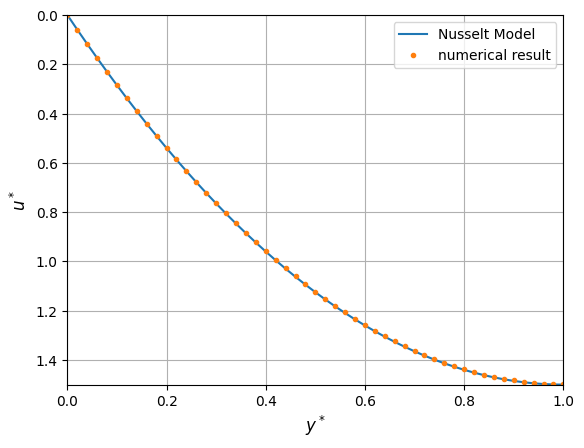

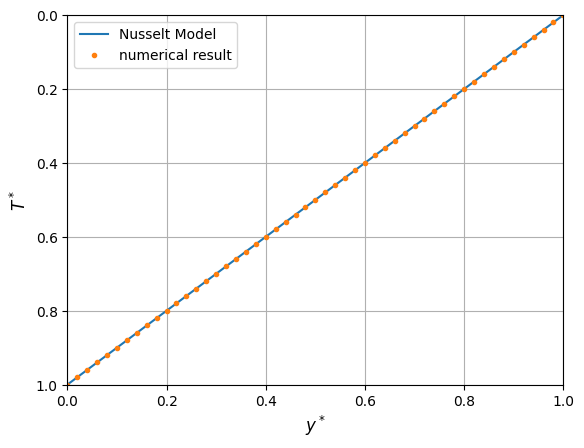

In [67]:
# Nusselt Model (corrected by Rohsenow) --------------------------------------------

# Ja = 0, H=Ja/Pr=0, dudy(1)= 0

# This case can be obtained analytically, but it is included here as an initial test.

Ja = 0
H = 0
tol_error = 10**(-5)
omega = 0.5
order_u = 8
order_T = 4

u0 = y
T0 = y
dudy = 0 # it is refered at y*=1

error = 9999
iter = 0
while error > tol_error:

    [u,T] = calc_uT(u0, T0, Ja, H, order_u, order_T, omega, dudy)
    error = sym.integrate((u-u0)**2 + (T-T0)**2, (y,0,1)) + 0
    u0 = u
    T0 = T
    iter += 1


# Figures ------------------------------------

Dy=0.02
y_lin = np.arange(0,1+Dy,Dy)
u_func = sym.lambdify(y, u, 'numpy')
T_func = sym.lambdify(y, T, 'numpy')
uNu_func = sym.lambdify(y, u_Nu, 'numpy')
TNu_func = sym.lambdify(y, T_Nu, 'numpy')

fig =plt.figure()
ax = fig.gca()
ax.set_ylim([0, 1.5])
ax.set_xlim([0,1])
plt.xlabel(r'$y^*$', fontsize=12, rotation=0, color='black')
plt.ylabel(r'$u^*$', fontsize=12, rotation=90, color='black')
plt.plot(y_lin, uNu_func(y_lin), label='Nusselt Model')
plt.plot(y_lin, u_func(y_lin), marker='.', linestyle='', label='numerical result')
plt.gca().invert_yaxis()
plt.grid()
plt.legend()
plt.show()

fig =plt.figure()
ax = fig.gca()
ax.set_ylim([0, 1])
ax.set_xlim([0, 1])
plt.xlabel(r'$y^*$', fontsize=12, rotation=0, color='black')
plt.ylabel(r'$T^*$', fontsize=12, rotation=90, color='black')
plt.plot(y_lin, TNu_func(y_lin), label='Nusselt Model')
plt.plot(y_lin, T_func(y_lin), marker='.', linestyle='', label='numerical result')
plt.gca().invert_yaxis()
plt.grid()
plt.legend()
plt.show()

---- Solving for Ja=0.01000 ----
---- Solving for Ja=0.01259 ----
---- Solving for Ja=0.01585 ----
---- Solving for Ja=0.01995 ----
---- Solving for Ja=0.02512 ----
---- Solving for Ja=0.03162 ----
---- Solving for Ja=0.03981 ----
---- Solving for Ja=0.05012 ----
---- Solving for Ja=0.06310 ----
---- Solving for Ja=0.07943 ----
---- Solving for Ja=0.10000 ----
---- Solving for Ja=0.12589 ----
---- Solving for Ja=0.15849 ----
---- Solving for Ja=0.19953 ----
---- Solving for Ja=0.25119 ----
---- Solving for Ja=0.31623 ----
---- Solving for Ja=0.39811 ----
---- Solving for Ja=0.50119 ----
---- Solving for Ja=0.63096 ----
---- Solving for Ja=0.79433 ----
---- Solving for Ja=1.00000 ----
---- Solving for Ja=1.25893 ----
---- Solving for Ja=1.58489 ----
---- Solving for Ja=1.99526 ----
---- Solving for Ja=2.51189 ----
---- Solving for Ja=3.16228 ----
---- Solving for Ja=3.98107 ----
---- Solving for Ja=5.01187 ----
---- Solving for Ja=6.30957 ----
---- Solving for Ja=7.94328 ----
---- Solvi

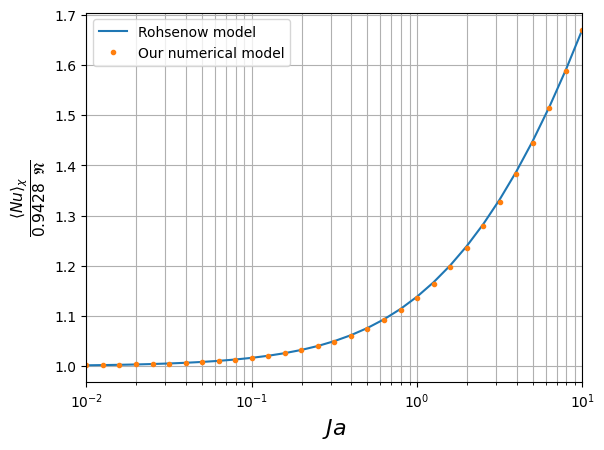

In [3]:
# Rohsenow Model (Fig. 2a) -----------------------------------------------------------------------

# H = 0 (which means Ja/Pr → 0) and dudy(1) = 0

H = 0
dudy = 0 # it is referred at y*=1

dZ = 0.1
Jas = 1*10.**(np.arange(-2, 1+dZ, dZ))
tol_error = 10**(-5)
order_u = 8
order_T = 4
omega = 0.5

# --------------------------------------------------------------------------

Nus = np.zeros(len(Jas))

# -------------------------------------------------------------------------

for k in range(len(Jas)):

    Ja = Jas[k]

    print('---- Solving for Ja={:.5f} ----'.format(Ja))

    u0 = u_Nu
    T0 = T_Nu
    
    error = 9999
    iter = 0

    while error > tol_error:

        [u,T] = calc_uT(u0, T0, Ja, H, order_u, order_T, omega, dudy)
        error = sym.integrate((u-u0)**2 + (T-T0)**2, (y,0,1)) + 0
        u0 = u
        T0 = T
        iter += 1
    
    dTdy0 = (sym.diff(T,y)).subs({y:0})
    [calG, calY] = calc_GY(u,T,Ja,H,dudy)
    Nus[k] = -4**(1/4)/(calY) * dTdy0

# Curve -------------------------------------------------------------

fig =plt.figure()
ax = fig.gca()
ax.set_xlim([Jas[0], Jas[-1]])
plt.xlabel(r'$Ja$', fontsize=16, rotation=0, color='black')
plt.ylabel(r'$\frac{\left< Nu \right>_\chi}{0.9428 \; \; \mathfrak{N}}$', fontsize=16, rotation=90, color='black')
plt.plot(Jas, (1+0.68*Jas)**0.25, label='Rohsenow model')
plt.plot(Jas, Nus, label='Our numerical model', linestyle='', marker='.')
plt.legend()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.set_xscale('log')
plt.grid(which='both')
plt.show()

 
--- Is the term associated with the factor 1/(R*R) neglected?... Q = False
 
Case Q=False, UD=0, R=10 --------
---- Solving for Ja=0.00100 ----
---- Solving for Ja=0.00126 ----
---- Solving for Ja=0.00158 ----
---- Solving for Ja=0.00200 ----
---- Solving for Ja=0.00251 ----
---- Solving for Ja=0.00316 ----
---- Solving for Ja=0.00398 ----
---- Solving for Ja=0.00501 ----
---- Solving for Ja=0.00631 ----
---- Solving for Ja=0.00794 ----
---- Solving for Ja=0.01000 ----
 
Case Q=False, UD=2, R=10 --------
---- Solving for Ja=0.00070 ----
---- Solving for Ja=0.00088 ----
---- Solving for Ja=0.00111 ----
---- Solving for Ja=0.00140 ----
---- Solving for Ja=0.00176 ----
---- Solving for Ja=0.00221 ----
---- Solving for Ja=0.00279 ----
---- Solving for Ja=0.00351 ----
---- Solving for Ja=0.00442 ----
---- Solving for Ja=0.00556 ----
---- Solving for Ja=0.00700 ----
 
Case Q=False, UD=0, R=100 --------
---- Solving for Ja=0.00100 ----
---- Solving for Ja=0.00126 ----
---- Solving for Ja=0.

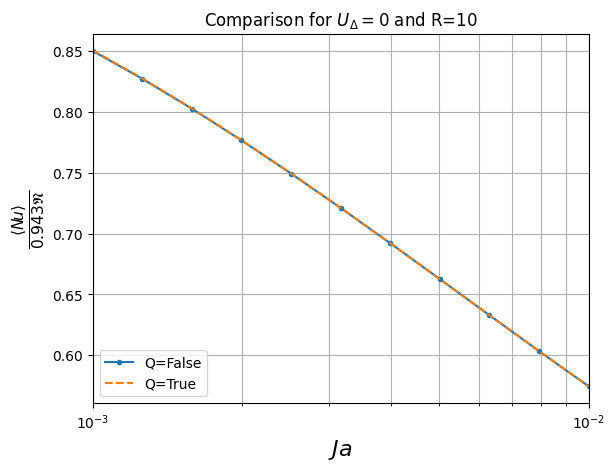

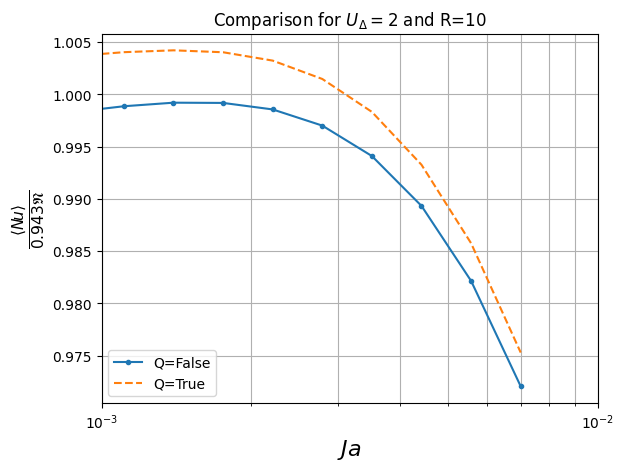

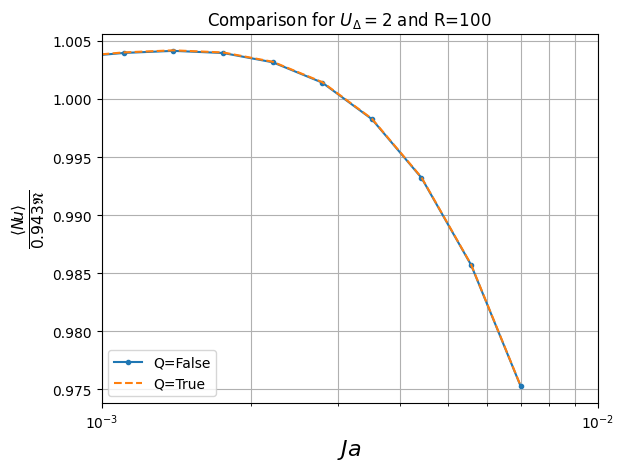

In [5]:
# Neglecting the term associated with the factor 1/(R*R)

UDs = np.array([0,2]) # This refers to U_{\Delta}
Pr = 0.001
dZ=0.1
Jas = np.array([10.**(np.arange(-3, -2+dZ, dZ)),7*10.**(np.arange(-4, -3+dZ, dZ))])
Qs = np.array([False,True])

tol_error = 10**(-5)
order_u = 8
order_T = 4
omega = 0.5

Rs = np.array([10,100])

ratio_QRUJ = np.empty((len(Qs), len(Rs), len(UDs), len(Jas[0])), dtype=object)

for l in range(len(Qs)):
    Q = Qs[l]
    print(' ')
    print('--- Is the term associated with the factor 1/(R*R) neglected?... Q =', Q)
    for k in range(len(Rs)):
        R = Rs[k]
        for j in range(len(UDs)):
            UD = UDs[j]
            print(' ')
            if Q==False:
                print('Case Q={}, UD={}, R={} --------'.format(Q,UD,R))
            if Q==True:
                print('Case Q={}, U_D={} --------'.format(Q,UD))
            for i in range(len(Jas[0])):
        
                Ja = Jas[j,i]
                H = Ja/Pr

                print('---- Solving for Ja={:.5f} ----'.format(Ja))

                u0 = u_Nu
                T0 = T_Nu
                
                if i==0:
                    dudy0 = 0.01
    
                error = 9999
                iter = 0

                while error > tol_error:

                    [u,T] = calc_uT(u0, T0, Ja, H, order_u, order_T, omega, dudy0)
                    U = calc_U(u,UD)
                    [calG,calY] = calc_GY(u,T,Ja,H,dudy0)
                    dudy=calc_dudy(H,calG,calY,R,u,U,dudy0,Q)
                
                    error = sym.integrate((u-u0)**2 + (T-T0)**2 , (y,0,1)) + np.abs(dudy-dudy0)
                    u0 = u
                    T0 = T
                    dudy0 = dudy
                    iter += 1

                ratio_QRUJ[l,k,j,i] = calc_factor(T,calY)
        if Q==True:
            break

fig =plt.figure()
ax = fig.gca()
ax.set_xlim([10e-4, 10e-3])
plt.title(r'Comparison for $U_{{\Delta}}=0$ and R=10')
plt.xlabel(r'$Ja$', fontsize=16, rotation=0, color='black')
plt.ylabel(r'$\frac{\left< N \! u \right>}{0.943 \mathfrak{N}}$', fontsize=16, rotation=90, color='black')
plt.plot(Jas[0], ratio_QRUJ[0,0,0], label='Q=False', marker='.')
plt.plot(Jas[0], ratio_QRUJ[1,0,0], label='Q=True', ls='--')
plt.legend()
ax.set_xscale('log')
ax.legend(loc='lower left')
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.grid(which='both')
plt.show()

fig =plt.figure()
ax = fig.gca()
ax.set_xlim([10e-4, 10e-3])
plt.title(r'Comparison for $U_{{\Delta}}=2$ and R=10')
plt.xlabel(r'$Ja$', fontsize=16, rotation=0, color='black')
plt.ylabel(r'$\frac{\left< N \! u \right>}{0.943 \mathfrak{N}}$', fontsize=16, rotation=90, color='black')
plt.plot(Jas[1], ratio_QRUJ[0,0,1], label='Q=False', marker='.')
plt.plot(Jas[1], ratio_QRUJ[1,0,1], label='Q=True', ls='--')
plt.legend()
ax.set_xscale('log')
ax.legend(loc='lower left')
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.grid(which='both')
plt.show()

fig =plt.figure()
ax = fig.gca()
ax.set_xlim([10e-4, 10e-3])
plt.title(r'Comparison for $U_{{\Delta}}=2$ and R=100')
plt.xlabel(r'$Ja$', fontsize=16, rotation=0, color='black')
plt.ylabel(r'$\frac{\left< N \! u \right>}{0.943 \mathfrak{N}}$', fontsize=16, rotation=90, color='black')
plt.plot(Jas[1], ratio_QRUJ[0,1,1], label='Q=False', marker='.')
plt.plot(Jas[1], ratio_QRUJ[1,0,1], label='Q=True', ls='--')
plt.legend()
ax.set_xscale('log')
ax.legend(loc='lower left')
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.grid(which='both')
plt.show()

------ Solving for UD=0.0, Pr=0.01 ------
------ Solving for UD=0.0, Pr=0.07 ------
------ Solving for UD=0.0, Pr=1.0 ------
------ Solving for UD=1.0, Pr=0.01 ------
------ Solving for UD=1.0, Pr=0.07 ------
------ Solving for UD=1.0, Pr=1.0 ------
------ Solving for UD=2.0, Pr=0.01 ------
------ Solving for UD=2.0, Pr=0.07 ------
------ Solving for UD=2.0, Pr=1.0 ------
------ Solving for UD=3.0, Pr=0.01 ------
------ Solving for UD=3.0, Pr=0.07 ------
------ Solving for UD=3.0, Pr=1.0 ------
------ Solving for UD=4.0, Pr=0.01 ------
------ Solving for UD=4.0, Pr=0.07 ------
------ Solving for UD=4.0, Pr=1.0 ------
------ Solving for UD=5.0, Pr=0.01 ------
------ Solving for UD=5.0, Pr=0.07 ------
------ Solving for UD=5.0, Pr=1.0 ------
------ Solving for UD=6.0, Pr=0.01 ------
------ Solving for UD=6.0, Pr=0.07 ------
------ Solving for UD=6.0, Pr=1.0 ------
------ Solving for UD=8.8, Pr=0.01 ------
------ Solving for UD=8.8, Pr=0.07 ------
------ Solving for UD=8.8, Pr=1.0 ------


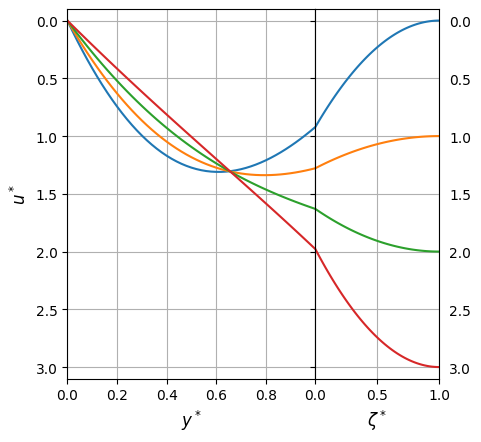

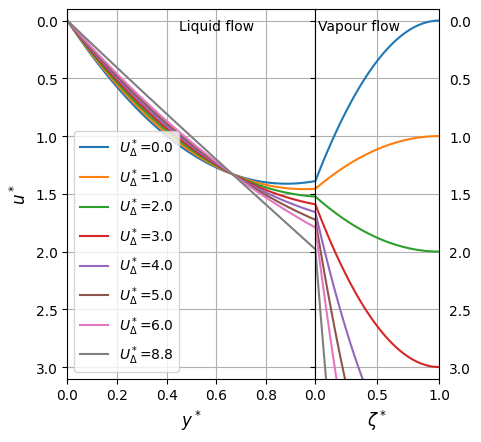

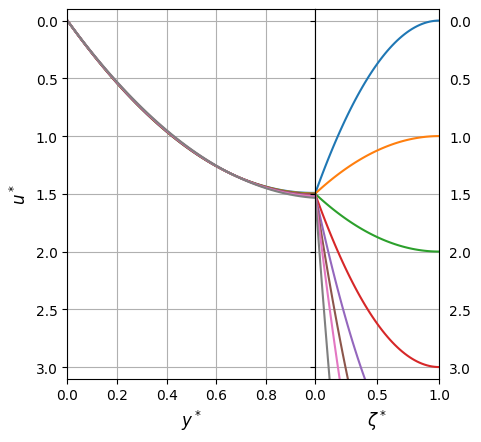

In [66]:
# Figure 5-------------------------------------------------------------------------------------

UDs = np.array([0,1,2,3,4,5,6,8.8]) 
Prs = np.array([0.01,0.07,1]) 
Ja = 0.02
tol_error = 10**(-5)
order_u = 8
order_T = 4
omega = 0.5
R = 100

# --------------------------------------------------------------------------

ru_UP = np.empty((len(UDs), len(Prs)), dtype=object)
rU_UP = np.empty((len(UDs), len(Prs)), dtype=object)

for j in range(len(UDs)):
    for i in range(len(Prs)):

        u0 = u_Nu
        T0 = T_Nu
        dudy0 = 0.01
        
        UD = UDs[j]
        Pr = Prs[i]
        H = Ja/Pr

        print('------ Solving for UD={}, Pr={} ------'.format(UD,Pr))
    
        error = 9999
        iter = 0
    
        while error > tol_error:

            if Pr==0.01 and UD>3.1:
                break

            [u,T] = calc_uT(u0, T0, Ja, H, order_u, order_T, omega, dudy0)
            U = calc_U(u,UD)
            [calG,calY] = calc_GY(u,T,Ja,H,dudy0)
            dudy=calc_dudy(H,calG,calY,R,u,U,dudy0,True)
                
            error = sym.integrate((u-u0)**2 + (T-T0)**2 , (y,0,1)) + np.abs(dudy-dudy0)
            u0 = u
            T0 = T
            dudy0 = dudy
            iter += 1

        ru_UP[j,i]=sym.lambdify(y, u, 'numpy')
        rU_UP[j,i]=sym.lambdify(z, U, 'numpy')

# Figures --------------------------------------------------

Dy=0.01
y_lin = np.arange(0,1+Dy,Dy)


# Figura 5a -----------------------------------------------

plt.subplot(121)
plt.xlim((0,1))
plt.ylim((-0.1,3.1))
plt.xlabel(r'$y^*$', fontsize=12, rotation=0, color='black')
plt.ylabel(r'$u^*$', fontsize=12, rotation=90, color='black')
for i in range(4):
    plt.plot(y_lin, ru_UP[i,0](y_lin))
plt.gca().invert_yaxis()
ax = plt.gca()
xticks = ax.get_xticks()
ax.set_xticks(xticks[:-1])
plt.grid()

plt.subplot(143)
plt.xlim((0,1))
plt.ylim((-0.1,3.1))
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.xlabel(r'$\zeta^*$', fontsize=12, rotation=0, color='black')
for i in range(4):
    plt.plot(y_lin, rU_UP[i,0](y_lin))
plt.gca().invert_yaxis()
plt.grid()
plt.subplots_adjust(wspace=0)

plt.show()


# Figura 5b -----------------------------------------------

plt.subplot(121)
plt.xlim((0,1))
plt.ylim((-0.1,3.1))
plt.xlabel(r'$y^*$', fontsize=12, rotation=0, color='black')
plt.ylabel(r'$u^*$', fontsize=12, rotation=90, color='black')
for i in range(len(UDs)):
    plt.plot(y_lin, ru_UP[i,1](y_lin), label=r'$U^*_\Delta$={}'.format(UDs[i]))
plt.gca().invert_yaxis()
ax = plt.gca()
xticks = ax.get_xticks()
ax.set_xticks(xticks[:-1])
plt.text(0.45, 0.08, 'Liquid flow')
plt.legend(loc='lower left')
plt.grid()

plt.subplot(143)
plt.xlim((0,1))
plt.ylim((-0.1,3.1))
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.xlabel(r'$\zeta^*$', fontsize=12, rotation=0, color='black')
for i in range(len(UDs)):
    plt.plot(y_lin, rU_UP[i,1](y_lin))
plt.gca().invert_yaxis()
plt.grid()
plt.subplots_adjust(wspace=0)
plt.text(0.02, 0.08, 'Vapour flow')

plt.show()


# Figura 5c -----------------------------------------------

plt.subplot(121)
plt.xlim((0,1))
plt.ylim((-0.1,3.1))
plt.xlabel(r'$y^*$', fontsize=12, rotation=0, color='black')
plt.ylabel(r'$u^*$', fontsize=12, rotation=90, color='black')
for i in range(len(UDs)):
    plt.plot(y_lin, ru_UP[i,2](y_lin), label=r'$U^*_\Delta$={}'.format(UDs[i]))
plt.gca().invert_yaxis()
ax = plt.gca()
xticks = ax.get_xticks()
ax.set_xticks(xticks[:-1])
plt.grid()

plt.subplot(143)
plt.xlim((0,1))
plt.ylim((-0.1,3.1))
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.xlabel(r'$\zeta^*$', fontsize=12, rotation=0, color='black')
for i in range(len(UDs)):
    plt.plot(y_lin, rU_UP[i,2](y_lin))
plt.gca().invert_yaxis()
plt.grid()
plt.subplots_adjust(wspace=0)

plt.show()
